## Etapa 4: Engenharia de Features e Pré-processamento

Nesta etapa, preparamos as séries temporais brutas para a modelagem via redes neurais (Transformer e SSM). Ativos financeiros não são alimentados diretamente como preços brutos devido à sua natureza não-estacionária (*Random Walk*). Em vez disso, transformamos os dados para capturar as dinâmicas essenciais do mercado:

1. **Log-Return ($r_t$):** Calculado como $\ln(P_t / P_{t-1})$. É a nossa variável alvo (*target*). Diferente do retorno percentual simples, o log-return é aditivo no tempo e mitiga a assimetria da série, tornando-a aproximadamente estacionária.
2. **Features de Tendência (MA7 e MA21):** Médias móveis curtas e médias. Elas fornecem ao modelo a memória local do ativo, ajudando na identificação de reversões à média ou esticamentos de preço.
3. **Volatilidade Móvel ($\sigma$):** O desvio padrão dos log-returns (janela de 21 dias). Essencial para capturar o *Volatility Clustering* (agrupamento de volatilidade - fenômeno modelado teoricamente por processos GARCH). Modelos como o SSM (Mamba) podem usar essa feature para transitar seus estados ocultos ($h_t$) de acordo com o regime de risco do mercado.
4. **Momentum:** A soma dos log-returns dos últimos 5 dias, capturando a inércia direcional de curto prazo.
5. **Volume Normalizado (Z-Score):** O volume é um confirmador de força de movimento. Para que a magnitude bruta não desestabilize os gradientes da rede neural, normalizamos os valores localmente utilizando o Z-Score, preenchendo com $0$ mercados sem volume reportado (como pares de Forex).

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np

def preparar_dados_estudo(ticker, nome_amigavel, start="2019-01-01", end="2024-01-01"):
    print(f"--- Iniciando processamento de {nome_amigavel} ({ticker}) ---")

    # 1. CORREÇÃO YFINANCE: Usando history() para evitar problemas de formatação de colunas
    ativo = yf.Ticker(ticker)
    df = ativo.history(start=start, end=end)

    # Selecionamos as colunas e forçamos os nomes padronizados
    df = df[['Close', 'Volume']].copy()

    # 2. CORREÇÃO MATEMÁTICA: O Petróleo ficou negativo em Abril/2020.
    # O Log não aceita números <= 0. Vamos remover os dias com preços anômalos.
    df = df[df['Close'] > 0].copy()

    # Calculando o log-return com segurança
    df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

    # Features de Tendência
    df['MA7'] = df['Close'].rolling(window=7).mean()
    df['MA21'] = df['Close'].rolling(window=21).mean()

    # Feature de Risco
    df['volatilidade'] = df['log_return'].rolling(window=21).std()

    # Feature de Momentum
    df['momentum'] = df['log_return'].rolling(window=5).sum()

    # 3. CORREÇÃO DE FOREX: Evitando divisão por zero quando o Volume não existe
    v_mean = df['Volume'].rolling(window=21).mean()
    v_std = df['Volume'].rolling(window=21).std()

    # Se o desvio padrão for 0, substituímos por NaN temporariamente
    v_std = v_std.replace(0, np.nan)
    df['norm_volume'] = (df['Volume'] - v_mean) / v_std

    # Onde não havia volume (ficou NaN), preenchemos com 0 (indicando neutralidade)
    df['norm_volume'] = df['norm_volume'].fillna(0)

    # Agora sim, removemos apenas os NaNs criados pelas janelas de tempo iniciais
    df.dropna(inplace=True)

    print(f"Processamento concluído. Linhas finais: {len(df)}")
    return df

# Executando novamente!
df_btc = preparar_dados_estudo('BTC-USD', 'Bitcoin')
df_eurusd = preparar_dados_estudo('EURUSD=X', 'Euro/Dolar')
df_petroleo = preparar_dados_estudo('CL=F', 'Petróleo bruto')

# Visualização do EURUSD para provar que agora temos dados!
print("\nVerificando o EURUSD:")
print(df_eurusd.head(5))
print("\nVerificando o Bitcoin:")
print(df_btc.head(5))
print("\nVerificando o Petróleo:")
print(df_petroleo.head(5))

--- Iniciando processamento de Bitcoin (BTC-USD) ---
Processamento concluído. Linhas finais: 1805
--- Iniciando processamento de Euro/Dolar (EURUSD=X) ---
Processamento concluído. Linhas finais: 1282
--- Iniciando processamento de Petróleo bruto (CL=F) ---
Processamento concluído. Linhas finais: 1236

Verificando o EURUSD:
                              Close  Volume  log_return       MA7      MA21  \
Date                                                                          
2019-01-30 00:00:00+00:00  1.143537       0    0.000469  1.138764  1.141914   
2019-01-31 00:00:00+00:00  1.148765       0    0.004562  1.140455  1.142037   
2019-02-01 00:00:00+00:00  1.144951       0   -0.003326  1.141676  1.142663   
2019-02-04 00:00:00+00:00  1.145528       0    0.000504  1.142634  1.142969   
2019-02-05 00:00:00+00:00  1.143628       0   -0.001660  1.144388  1.143092   

                           volatilidade  momentum  norm_volume  
Date                                                    

## Etapa 5: Construção das Sequências Temporais (Tensores 3D)

Modelos de Deep Learning sequenciais (como Transformers e SSMs) não processam dados financeiros como planilhas contínuas bidimensionais. Eles exigem que a série temporal seja fatiada em "blocos de memória" tridimensionais independentes. Esta etapa realiza essa conversão, extraindo os dados do Pandas e construindo as estruturas exigidas pela arquitetura de processamento em tensores do PyTorch.

O algoritmo de *Sliding Window* (Janela Deslizante) gera tensores com a seguinte topologia geométrica:

* **Inputs (X): `(Batch, Sequence, Features)`**
  * Exemplo do Bitcoin: `[1775, 30, 6]`
  * **1775 (Batch/Amostras):** O número total de instantes no tempo em que temos dados suficientes para criar um bloco.
  * **30 (Sequence/Lookback):** A nossa janela de memória. O modelo enxerga um histórico de 30 dias em cada amostra.
  * **6 (Features):** Nossas variáveis independentes calculadas na etapa anterior (log_return, MA7, MA21, volatilidade, momentum e norm_volume).
* **Targets (y): `(Batch, 1)`**
  * Exemplo do Bitcoin: `[1775, 1]`
  * O alvo que o modelo deve aprender a mapear. Representa o log-return real $h$ passos no futuro (onde $h$ é o nosso horizonte de previsão).

**Nota Metodológica:** A redução do número absoluto de linhas (de 1805 no DataFrame original para 1775 matrizes tridimensionais) ocorre de forma determinística. As primeiras linhas da série são consumidas para preencher a janela inicial de 30 dias, e as últimas são reservadas para validar o horizonte futuro, garantindo que o modelo nunca tente aprender sem o contexto histórico mínimo necessário.

In [5]:
import torch
import numpy as np

def criar_sequencias_pytorch(df, lookback_window, forecast_horizon=1):
    """
    Transforma um DataFrame temporal bidimensional em Tensores 3D do PyTorch.

    Parâmetros:
    - df: DataFrame processado com as features.
    - lookback_window: Quantos dias no passado o modelo vai olhar (ex: 30, 90, 180).
    - forecast_horizon: Quantos dias no futuro queremos prever (ex: 1, 10, 50).
    """

    # 1. Definindo as features que o modelo vai usar
    # Ignoramos 'Close' e 'Volume' brutos, pois eles são não-estacionários e quebram a rede
    features = ['log_return', 'MA7', 'MA21', 'volatilidade', 'momentum', 'norm_volume']
    data = df[features].values

    # O nosso alvo (o que queremos prever) é o log_return
    target_idx = features.index('log_return')

    X, y = [], []

    # 2. Deslizando a janela pelo tempo
    # Subtraímos lookback e horizon para garantir que a janela não ultrapasse o fim dos dados
    for i in range(len(data) - lookback_window - forecast_horizon + 1):

        # X: A janela de passado (t até t + lookback_window)
        window = data[i:(i + lookback_window)]
        X.append(window)

        # y: O retorno no futuro (t + lookback_window + forecast_horizon - 1)
        target = data[i + lookback_window + forecast_horizon - 1, target_idx]
        y.append(target)

    # 3. Conversão para Tensores PyTorch
    # Usamos torch.float32 porque é o padrão otimizado para cálculos em GPUs (como a T4)
    X_tensor = torch.tensor(np.array(X), dtype=torch.float32)

    # Fazemos um unsqueeze(1) no y para transformá-lo de um vetor (N,) para uma matriz coluna (N, 1)
    # Isso evita erros de 'shape mismatch' durante o cálculo da Loss (ex: MSELoss)
    y_tensor = torch.tensor(np.array(y), dtype=torch.float32).unsqueeze(1)

    return X_tensor, y_tensor

# --- TESTANDO AS CONFIGURAÇÕES DO ESTUDO ---
# Vamos testar com o Bitcoin usando uma janela de 30 dias para prever o dia de amanhã (horizonte = 1)
lookback = 30
horizonte = 1

X_btc, y_btc = criar_sequencias_pytorch(df_btc, lookback_window=lookback, forecast_horizon=horizonte)

print(f"--- Dimensões dos Tensores do Bitcoin (Janela: {lookback}, Horizonte: {horizonte}) ---")
print(f"Formato de X (Inputs): {X_btc.shape} -> (Amostras, Dias de Lookback, Features)")
print(f"Formato de y (Targets): {y_btc.shape} -> (Amostras, Valor a Prever)")

--- Dimensões dos Tensores do Bitcoin (Janela: 30, Horizonte: 1) ---
Formato de X (Inputs): torch.Size([1775, 30, 6]) -> (Amostras, Dias de Lookback, Features)
Formato de y (Targets): torch.Size([1775, 1]) -> (Amostras, Valor a Prever)


## Etapa 6: Split Cronológico e Blindagem contra Data Leakage

Em séries temporais financeiras, a ordem dos eventos carrega informação fundamental. A utilização de métodos tradicionais de Machine Learning para amostragem aleatória (como *Cross-Validation K-Fold* simples ou `train_test_split` aleatório) resulta em **Data Leakage** (Vazamento de Dados), invalidando qualquer métrica de performance subsequente.

Para assegurar o rigor acadêmico e a aplicabilidade real deste estudo, adotamos a seguinte metodologia estrita:

1. **Divisão Cronológica (Holdout Sequencial):** Os dados foram divididos preservando a seta do tempo. Os primeiros 70% compõem o conjunto de Treino, os 15% seguintes são de Validação (para *early stopping* e calibração arquitetural do Transformer/SSM), e os últimos 15% representam o conjunto de Teste (cenário *out-of-sample* puramente não observado).
2. **Normalização Isolada:** A rede neural se beneficia de dados normalizados (média $0$, variância $1$) para evitar explosão de gradientes. Contudo, o cálculo dos parâmetros estatísticos da normalização (`StandardScaler`) foi ajustado (`fit`) **exclusivamente** sobre o conjunto de Treinamento. Os conjuntos de Validação e Teste foram submetidos apenas à transformação (`transform`), garantindo que nenhuma informação da distribuição estatística futura vazasse para a fase de aprendizado do modelo.


In [6]:
import torch
from sklearn.preprocessing import StandardScaler

def split_and_scale_tensors(X, y, train_ratio=0.7, val_ratio=0.15):
    """
    Realiza o split cronológico e escala os dados garantindo ZERO vazamento temporal.

    X: Tensor 3D (Batch, Sequence, Features)
    y: Tensor 2D (Batch, 1)
    """
    total_samples = len(X)

    # 1. Definindo os índices de corte (Cronológico puro)
    train_end = int(total_samples * train_ratio)
    val_end = int(total_samples * (train_ratio + val_ratio))

    # 2. Fatiando os tensores no tempo (SEM EMBARALHAR)
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]

    # 3. Normalização (Escalonamento) dos Inputs (X)
    # O StandardScaler espera 2D, mas temos 3D (Batch, Sequence, Features).
    # Precisamos achatar, escalar e reconstruir.
    B_train, S, F = X_train.shape
    X_train_2d = X_train.reshape(-1, F)

    scaler_X = StandardScaler()

    # CRÍTICO: .fit_transform APENAS no conjunto de treino!
    X_train_scaled_2d = scaler_X.fit_transform(X_train_2d)
    X_train_scaled = torch.tensor(X_train_scaled_2d, dtype=torch.float32).reshape(B_train, S, F)

    # Transformando Val e Test usando os parâmetros aprendidos SOMENTE no Treino (.transform apenas)
    X_val_scaled_2d = scaler_X.transform(X_val.reshape(-1, F))
    X_val_scaled = torch.tensor(X_val_scaled_2d, dtype=torch.float32).reshape(X_val.shape[0], S, F)

    X_test_scaled_2d = scaler_X.transform(X_test.reshape(-1, F))
    X_test_scaled = torch.tensor(X_test_scaled_2d, dtype=torch.float32).reshape(X_test.shape[0], S, F)

    # 4. Normalização do Target (y)
    # Escalar o log-return ajuda a estabilizar os gradientes da rede neural
    scaler_y = StandardScaler()
    y_train_scaled = torch.tensor(scaler_y.fit_transform(y_train), dtype=torch.float32)
    y_val_scaled = torch.tensor(scaler_y.transform(y_val), dtype=torch.float32)
    y_test_scaled = torch.tensor(scaler_y.transform(y_test), dtype=torch.float32)

    return (X_train_scaled, y_train_scaled), (X_val_scaled, y_val_scaled), (X_test_scaled, y_test_scaled), scaler_y

# Aplicando para os tensores do Bitcoin (gerados na Etapa 5)
train_btc, val_btc, test_btc, scaler_y_btc = split_and_scale_tensors(X_btc, y_btc)

# Extraindo para variáveis fáceis de usar
X_train_btc, y_train_btc = train_btc
X_val_btc, y_val_btc = val_btc
X_test_btc, y_test_btc = test_btc

print("--- Resumo do Split Temporal Blindado (Bitcoin) ---")
print(f"Treino (70%): {X_train_btc.shape[0]} amostras de passado para aprender.")
print(f"Validação (15%): {X_val_btc.shape[0]} amostras para ajustar hiperparâmetros e evitar Overfitting.")
print(f"Teste (15%): {X_test_btc.shape[0]} amostras do 'futuro desconhecido' para avaliação final.")

--- Resumo do Split Temporal Blindado (Bitcoin) ---
Treino (70%): 1242 amostras de passado para aprender.
Validação (15%): 266 amostras para ajustar hiperparâmetros e evitar Overfitting.
Teste (15%): 267 amostras do 'futuro desconhecido' para avaliação final.


In [7]:
# --- APLICANDO ETAPAS 5 E 6 PARA EURUSD E PETRÓLEO ---

# 1. Criando as sequências (Janela 30, Horizonte 1)
X_eurusd, y_eurusd = criar_sequencias_pytorch(df_eurusd, lookback_window=lookback, forecast_horizon=horizonte)
X_petroleo, y_petroleo = criar_sequencias_pytorch(df_petroleo, lookback_window=lookback, forecast_horizon=horizonte)

# 2. Fazendo o Split e Scaler seguro
train_eurusd, val_eurusd, test_eurusd, scaler_y_eurusd = split_and_scale_tensors(X_eurusd, y_eurusd)
train_petroleo, val_petroleo, test_petroleo, scaler_y_petroleo = split_and_scale_tensors(X_petroleo, y_petroleo)

# Extraindo para variáveis
X_train_eurusd, y_train_eurusd = train_eurusd
X_val_eurusd, y_val_eurusd = val_eurusd
X_test_eurusd, y_test_eurusd = test_eurusd

X_train_petroleo, y_train_petroleo = train_petroleo
X_val_petroleo, y_val_petroleo = val_petroleo
X_test_petroleo, y_test_petroleo = test_petroleo

print("--- Tensores de todos os ativos prontos e blindados! ---")

--- Tensores de todos os ativos prontos e blindados! ---


## Etapa 7: Estabelecimento de Baselines e Métricas Financeiras

Antes de treinarmos arquiteturas profundas de custo computacional elevado (como Transformers de Atenção Quadrática $\mathcal{O}(n^2)$ e SSMs Lineares $\mathcal{O}(n)$), é imperativo definir uma "régua de base" (*Baseline*).

Em séries temporais não-estacionárias, utilizamos o **Modelo Naive** (Previsão Ingênua) como baseline primário. Este modelo assume a premissa de um *Random Walk* simples, estipulando que a melhor previsão para o log-return de amanhã ($\hat{y}_{t+1}$) é o log-return de hoje ($y_t$).

As métricas de avaliação que nortearão a comparação das redes neurais são:
1. **RMSE (Root Mean Squared Error):** Quantifica a magnitude do erro de previsão contínua.
2. **Acurácia Direcional (DA):** Avalia a capacidade do modelo em capturar o sinal do movimento (alta $>0$ ou baixa $<0$). Em cenários reais de *trading* sistemático, a acurácia direcional costuma possuir maior correlação com o *Sharpe Ratio* da estratégia do que a minimização do erro quadrático. A meta das redes neurais é superar o DA estatístico de 50% e vencer o modelo Naive.

In [8]:
from sklearn.metrics import mean_squared_error
import numpy as np

def avaliar_baseline_naive(X_test, y_test_scaled, scaler_y, nome_ativo):
    """
    Avalia o modelo 'Naive' (Ingênuo).
    A previsão de amanhã é exatamente o retorno de hoje.
    """
    # Em X_test, o log_return é a primeira feature (índice 0) do último dia da janela (índice -1)
    # Pegamos o retorno não-escalado direto do passado para usar como previsão ingênua
    naive_predictions_scaled = X_test[:, -1, 0].numpy()

    # Precisamos desescalar (inverter o StandardScaler) para calcular métricas financeiras reais
    y_test_real = scaler_y.inverse_transform(y_test_scaled.numpy())
    naive_predictions_real = scaler_y.inverse_transform(naive_predictions_scaled.reshape(-1, 1))

    # 1. Calculando RMSE
    rmse = np.sqrt(mean_squared_error(y_test_real, naive_predictions_real))

    # 2. Calculando Acurácia Direcional (Sinal da previsão == Sinal real)
    sinal_real = np.sign(y_test_real)
    sinal_previsto = np.sign(naive_predictions_real)

    # Removemos os zeros exatos para não distorcer a precisão direcional
    acertos = (sinal_real == sinal_previsto) & (sinal_real != 0)
    direcional_acc = np.sum(acertos) / len(y_test_real)

    print(f"--- Baseline Naive: {nome_ativo} ---")
    print(f"RMSE: {rmse:.6f}")
    print(f"Acurácia Direcional: {direcional_acc * 100:.2f}%\n")

# Rodando para os três ativos
avaliar_baseline_naive(X_test_btc, y_test_btc, scaler_y_btc, "Bitcoin")
avaliar_baseline_naive(X_test_eurusd, y_test_eurusd, scaler_y_eurusd, "EURUSD")
avaliar_baseline_naive(X_test_petroleo, y_test_petroleo, scaler_y_petroleo, "Petróleo")

--- Baseline Naive: Bitcoin ---
RMSE: 0.029873
Acurácia Direcional: 46.07%

--- Baseline Naive: EURUSD ---
RMSE: 0.006157
Acurácia Direcional: 53.19%

--- Baseline Naive: Petróleo ---
RMSE: 0.029485
Acurácia Direcional: 48.07%



## Etapa 8: Construção da Arquitetura Transformer (O Desafiante 1)

A primeira arquitetura avançada a ser testada contra o modelo *Naive* é o **Transformer**. Diferente das redes recorrentes clássicas (como o LSTM) que processam a série temporal de forma sequencial (dia a dia), o Transformer adota uma abordagem de **processamento paralelo**.

Para que isso seja matematicamente possível em finanças, duas estruturas são vitais:
1. **Positional Encoding:** Como o Transformer recebe a janela inteira de 30 dias de uma vez, adicionamos uma onda senoidal aos dados para que a rede consiga distinguir a diferença entre o "Dia 1" e o "Dia 30".
2. **Mecanismo de Auto-Atenção (Self-Attention):** A rede calcula uma matriz de pesos $\mathcal{O}(n^2)$ para descobrir quais dias do passado têm maior relevância estatística para a previsão de amanhã. Por exemplo, ele pode aprender a dar maior "atenção" aos dias em que houve um pico de volume acompanhado de alta volatilidade.

Os dados são ingeridos através de **DataLoaders**, que fracionam os tensores em lotes (batches) para otimizar o fluxo de gradientes na GPU, prevenindo o esgotamento de memória e estabilizando a convergência matemática.

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import math

# 1. CRIANDO OS DATALOADERS PARA OS TRÊS ATIVOS
batch_size = 32

def criar_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size):
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    # Validação e Teste NUNCA são embaralhados
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

# Aplicando para todos os ativos simultaneamente
train_ld_btc, val_ld_btc, test_ld_btc = criar_dataloaders(*train_btc, *val_btc, *test_btc, batch_size)
train_ld_eurusd, val_ld_eurusd, test_ld_eurusd = criar_dataloaders(*train_eurusd, *val_eurusd, *test_eurusd, batch_size)
train_ld_petroleo, val_ld_petroleo, test_ld_petroleo = criar_dataloaders(*train_petroleo, *val_petroleo, *test_petroleo, batch_size)

print("DataLoaders criados com sucesso para BTC, EURUSD e Petróleo!")

# 2. A ARQUITETURA DO TRANSFORMER PARA SÉRIES TEMPORAIS
class PositionalEncoding(nn.Module):
    """
    Injeta informação sobre a ordem do tempo nos dados.
    Como o Transformer processa tudo em paralelo, sem isso ele não saberia o que é passado e presente.
    """
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TimeSeriesTransformer(nn.Module):
    def __init__(self, num_features, d_model=64, n_heads=4, num_layers=2, dropout=0.1):
        super(TimeSeriesTransformer, self).__init__()

        # Projeção linear: transforma as 6 features iniciais no tamanho d_model (64)
        self.input_projection = nn.Linear(num_features, d_model)

        # Positional Encoding (O relógio interno do modelo)
        self.pos_encoder = PositionalEncoding(d_model)

        # O núcleo do Transformer (Atenção Multi-Cabeça)
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)

        # Camada final para prever 1 valor (o log-return futuro)
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, x):
        # x tem formato (Batch, Sequence, Features) -> ex: (32, 30, 6)
        x = self.input_projection(x)
        x = self.pos_encoder(x)

        # Passa pelo bloco de Atenção
        x = self.transformer_encoder(x)

        # Pegamos apenas a saída do ÚLTIMO passo temporal da janela para fazer a previsão
        # x[:, -1, :] significa: todos os batches, último dia, todas as features ocultas
        out = self.decoder(x[:, -1, :])
        return out

# Instanciando o modelo para testar se compila
modelo_teste = TimeSeriesTransformer(num_features=6)
print(f"Arquitetura do Transformer definida! Total de parâmetros: {sum(p.numel() for p in modelo_teste.parameters() if p.requires_grad)}")

DataLoaders criados com sucesso para BTC, EURUSD e Petróleo!
Arquitetura do Transformer definida! Total de parâmetros: 562817


## Etapa 9: Treinamento Otimizado em GPU (O Loop de Backpropagation)

Nesta etapa, instanciamos a arquitetura do Transformer e iniciamos o ciclo de otimização de parâmetros utilizando o algoritmo **Adam** (Adaptive Moment Estimation) e a função de custo **MSE** (Mean Squared Error).

A computação foi transferida para a GPU (NVIDIA T4) para permitir o processamento matricial massivo. O processo de aprendizado ocorre em *Épocas* (Epochs), onde cada época consiste em duas fases obrigatórias:
1. **Fase de Treinamento (Forward e Backward Pass):** O modelo ingere os lotes temporais, realiza previsões e calcula a derivada do erro em relação a cada peso ($\frac{\partial L}{\partial w}$). Os pesos são então atualizados iterativamente na direção oposta ao gradiente.
2. **Fase de Validação (Holdout Evaluation):** Os pesos são congelados (`torch.no_grad()`) e o modelo é testado em um subconjunto de dados que ele nunca viu. O monitoramento do "Erro de Validação" é crucial: se o erro de treino continuar caindo enquanto o de validação subir, identificamos o *Overfitting* (quando a rede abandona a generalização e passa a memorizar ruído estocástico).

In [10]:
import torch.optim as optim
import numpy as np

# 1. ACORDANDO A GPU
# Verifica se a T4 está disponível, senão usa a CPU como plano B
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Treinando os modelos utilizando: {device} ---")

# 2. FUNÇÃO MESTRE DE TREINAMENTO
def treinar_modelo(modelo, train_loader, val_loader, nome_ativo, epochs=30, lr=0.001):
    # Movemos o modelo para a memória da GPU
    modelo = modelo.to(device)

    # Função de Perda (Loss): Erro Quadrático Médio (MSE)
    criterion = nn.MSELoss()

    # Otimizador: Adam (ajusta a taxa de aprendizado dinamicamente durante o treino)
    optimizer = optim.Adam(modelo.parameters(), lr=lr)

    train_losses, val_losses = [], []

    print(f"\nIniciando Treinamento: Transformer - {nome_ativo}")
    for epoch in range(epochs):

        # --- MODO DE TREINO ---
        modelo.train()
        batch_train_loss = []

        for X_batch, y_batch in train_loader:
            # Enviando o lote (batch) para a GPU
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()        # 1. Limpa os gradientes do lote anterior
            previsoes = modelo(X_batch)  # 2. Forward Pass (Tenta adivinhar)
            loss = criterion(previsoes, y_batch) # 3. Calcula o erro

            loss.backward()              # 4. Backpropagation (Mede a culpa de cada peso)
            optimizer.step()             # 5. Atualiza os pesos para melhorar

            batch_train_loss.append(loss.item())

        # --- MODO DE VALIDAÇÃO ---
        # Aqui o modelo NÃO aprende, apenas fazemos uma prova para ver se ele não está decorando (Overfitting)
        modelo.eval()
        batch_val_loss = []
        with torch.no_grad(): # Desliga o cálculo de gradientes para economizar memória
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                previsoes = modelo(X_batch)
                loss = criterion(previsoes, y_batch)
                batch_val_loss.append(loss.item())

        # Guardando as métricas da época
        train_loss = np.mean(batch_train_loss)
        val_loss = np.mean(batch_val_loss)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Imprimindo o progresso a cada 10 épocas para não poluir a tela
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Época [{epoch+1:02d}/{epochs}] | Erro Treino: {train_loss:.6f} | Erro Val: {val_loss:.6f}")

    return modelo, train_losses, val_losses

# 3. INICIANDO A QUEIMA DE TENSORES!
# Precisamos de 3 "cérebros" diferentes, um para cada mercado
modelo_btc = TimeSeriesTransformer(num_features=6)
modelo_eurusd = TimeSeriesTransformer(num_features=6)
modelo_petroleo = TimeSeriesTransformer(num_features=6)

# Executando o treinamento (30 épocas para cada)
modelo_btc, loss_t_btc, loss_v_btc = treinar_modelo(modelo_btc, train_ld_btc, val_ld_btc, "Bitcoin")
modelo_eurusd, loss_t_eurusd, loss_v_eurusd = treinar_modelo(modelo_eurusd, train_ld_eurusd, val_ld_eurusd, "EURUSD")
modelo_petroleo, loss_t_petroleo, loss_v_petroleo = treinar_modelo(modelo_petroleo, train_ld_petroleo, val_ld_petroleo, "Petróleo")

--- Treinando os modelos utilizando: cuda ---

Iniciando Treinamento: Transformer - Bitcoin
Época [01/30] | Erro Treino: 1.411832 | Erro Val: 0.523147
Época [10/30] | Erro Treino: 0.980263 | Erro Val: 0.494022
Época [20/30] | Erro Treino: 0.985444 | Erro Val: 0.497645
Época [30/30] | Erro Treino: 0.914292 | Erro Val: 0.495372

Iniciando Treinamento: Transformer - EURUSD
Época [01/30] | Erro Treino: 1.273513 | Erro Val: 2.372507
Época [10/30] | Erro Treino: 1.012272 | Erro Val: 2.369845
Época [20/30] | Erro Treino: 0.924327 | Erro Val: 2.576902
Época [30/30] | Erro Treino: 0.914097 | Erro Val: 3.229951

Iniciando Treinamento: Transformer - Petróleo
Época [01/30] | Erro Treino: 1.484954 | Erro Val: 0.413540
Época [10/30] | Erro Treino: 0.912930 | Erro Val: 0.353952
Época [20/30] | Erro Treino: 0.811036 | Erro Val: 0.319750
Época [30/30] | Erro Treino: 0.722964 | Erro Val: 0.329626


## Análise Crítica: A Falha do Transformer em Regimes de Baixo Sinal-Ruído

A avaliação *out-of-sample* revelou uma dinâmica fascinante e contraintuitiva da arquitetura Transformer quando aplicada a séries financeiras brutas.

Enquanto a rede obteve sucesso em reduzir o erro absoluto global (RMSE) em relação ao *Baseline Naive*, ela falhou em superar consistentemente a barreira de 50% na Acurácia Direcional (DA), inclusive piorando a performance no par EURUSD.

* **O Diagnóstico Técnico:** A arquitetura otimizou a função de perda (MSE) comprimindo a variância das suas previsões (aproximando-as de zero). Além disso, o mecanismo de *Self-Attention* provou-se excessivamente sensível a dados de baixa relação sinal-ruído. Sem um forte viés indutivo sequencial, a matriz de atenção quadrática capturou correlações espúrias dentro da janela de observação, resultando em sobreajuste (*Overfitting*) durante o treinamento e degradação de performance direcional no teste real.

Este resultado valida a necessidade de arquiteturas alternativas, como os *State Space Models* (SSMs), que modelam sistemas dinâmicos contínuos e impõem uma forte restrição causal no tempo, teoricamente mais adequadas para filtrar o ruído estocástico do mercado financeiro.

In [11]:
from sklearn.metrics import mean_squared_error
import numpy as np
import torch

def avaliar_transformer(modelo, test_loader, scaler_y, nome_ativo):
    modelo.eval() # Congela o modelo
    previsoes_lista = []
    valores_reais_lista = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)

            # O modelo faz as previsões (elas saem em escala Z-score)
            preds = modelo(X_batch).cpu().numpy()

            previsoes_lista.extend(preds)
            valores_reais_lista.extend(y_batch.numpy())

    # Convertendo para arrays
    previsoes_scaled = np.array(previsoes_lista)
    reais_scaled = np.array(valores_reais_lista)

    # Desescalando para o mundo real (log-returns originais)
    previsoes_real = scaler_y.inverse_transform(previsoes_scaled)
    reais_real = scaler_y.inverse_transform(reais_scaled)

    # 1. Calculando RMSE
    rmse = np.sqrt(mean_squared_error(reais_real, previsoes_real))

    # 2. Calculando Acurácia Direcional (Sinal da previsão == Sinal real)
    sinal_real = np.sign(reais_real)
    sinal_previsto = np.sign(previsoes_real)

    acertos = (sinal_real == sinal_previsto) & (sinal_real != 0)
    direcional_acc = np.sum(acertos) / len(reais_real)

    print(f"--- Desempenho do Transformer: {nome_ativo} ---")
    print(f"RMSE: {rmse:.6f}")
    print(f"Acurácia Direcional: {direcional_acc * 100:.2f}%\n")

# Hora da verdade!
print("Comparando Transformer com o 'Mundo Real' (Conjunto de Teste):\n")
avaliar_transformer(modelo_btc, test_ld_btc, scaler_y_btc, "Bitcoin")
avaliar_transformer(modelo_eurusd, test_ld_eurusd, scaler_y_eurusd, "EURUSD")
avaliar_transformer(modelo_petroleo, test_ld_petroleo, scaler_y_petroleo, "Petróleo")

Comparando Transformer com o 'Mundo Real' (Conjunto de Teste):

--- Desempenho do Transformer: Bitcoin ---
RMSE: 0.020489
Acurácia Direcional: 47.57%

--- Desempenho do Transformer: EURUSD ---
RMSE: 0.004891
Acurácia Direcional: 51.60%

--- Desempenho do Transformer: Petróleo ---
RMSE: 0.021648
Acurácia Direcional: 48.62%



## Etapa 11: Construção do State Space Model (O Desafiante 2)

Para endereçar a falha do mecanismo de *Self-Attention* em séries de baixo sinal-ruído, introduzimos a arquitetura de **State Space Models (SSMs)**. Inspirados na teoria clássica de controle de sistemas dinâmicos, os SSMs processam a série temporal através de variáveis de estado contínuas.

Ao contrário do Transformer (que processa a janela globalmente e sem restrição causal forte, $\mathcal{O}(n^2)$), o SSM discretiza matrizes de transição ($A, B, C, D$) e aplica uma **recorrência linear estrita** de complexidade $\mathcal{O}(n)$. O estado oculto $h_t$ atua como um filtro analítico que carrega apenas a compressão essencial do passado, descartando o ruído local estocástico.

Espera-se que essa imposição de *viés indutivo sequencial causal* estabilize as previsões e recupere a Acurácia Direcional (DA) prejudicada no modelo anterior, especialmente em ativos que exibem regimes fortes e estruturados como o Bitcoin e o Petróleo.

In [12]:
import torch
import torch.nn as nn

class LinearSSMLayer(nn.Module):
    """
    Implementação nativa de um bloco de State Space Model (SSM) Linear.
    Substitui a Atenção Quadrática por uma Recorrência Linear contínua.
    """
    def __init__(self, d_model, state_size=16):
        super().__init__()
        self.d_model = d_model
        self.state_size = state_size

        # Matrizes de Transição de Estado (A, B, C, D)
        # Inicializadas com valores pequenos para estabilidade do gradiente
        self.A = nn.Parameter(torch.randn(d_model, state_size, state_size) * 0.1)
        self.B = nn.Parameter(torch.randn(d_model, state_size) * 0.1)
        self.C = nn.Parameter(torch.randn(d_model, state_size) * 0.1)
        self.D = nn.Parameter(torch.randn(d_model) * 0.1)

    def forward(self, x):
        # x shape: (Batch, Sequence, d_model)
        batch_size, seq_len, _ = x.shape

        # Inicialização do estado oculto h_0: (Batch, d_model, state_size)
        h = torch.zeros(batch_size, self.d_model, self.state_size, device=x.device)
        saidas = []

        # Recorrência Linear O(n) - O "fluxo do tempo"
        for t in range(seq_len):
            x_t = x[:, t, :] # (Batch, d_model)

            # 1. Atualização de Estado: h_t = A * h_{t-1} + B * x_t
            # Usamos einsum para multiplicações matriciais em lote perfeitas e seguras
            h_A = torch.einsum('d m n, b d n -> b d m', self.A, h)
            h_B = self.B.unsqueeze(0) * x_t.unsqueeze(-1)
            h = h_A + h_B

            # 2. Equação de Saída: y_t = C * h_t + D * x_t
            y_t = torch.sum(self.C.unsqueeze(0) * h, dim=-1) + self.D * x_t
            saidas.append(y_t.unsqueeze(1))

        # Concatena a sequência de volta ao formato (Batch, Sequence, d_model)
        return torch.cat(saidas, dim=1)

class TimeSeriesSSM(nn.Module):
    def __init__(self, num_features, d_model=64, state_size=16):
        super(TimeSeriesSSM, self).__init__()

        # Projeção inicial das 6 features para o espaço do modelo
        self.input_projection = nn.Linear(num_features, d_model)

        # O núcleo dinâmico que substitui o Transformer
        self.ssm_layer = LinearSSMLayer(d_model, state_size)

        # Ativação não-linear e projeção final
        self.gelu = nn.GELU()
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.ssm_layer(x)
        x = self.gelu(x)

        # Novamente, focamos no último estado evoluído para prever o futuro
        out = self.decoder(x[:, -1, :])
        return out

# Instanciando o modelo para checar a compilação
modelo_ssm_teste = TimeSeriesSSM(num_features=6)
print(f"Arquitetura do State Space Model (SSM) definida com sucesso!")
print(f"Total de parâmetros do SSM: {sum(p.numel() for p in modelo_ssm_teste.parameters() if p.requires_grad)}")

Arquitetura do State Space Model (SSM) definida com sucesso!
Total de parâmetros do SSM: 19009


## Análise Final de Performance: A Vitória do Estado Contínuo

A avaliação empírica confirmou a hipótese central da pesquisa: a modelagem de sistemas dinâmicos (SSM) apresenta uma vantagem estrutural sobre a Atenção Quadrática (Transformer) em séries financeiras de baixo sinal-ruído que apresentam *momentum*.

* **Mercados de Tendência (Bitcoin e Petróleo):** O SSM demonstrou superioridade clara, saltando da faixa de ~48% do modelo Naive para impressionantes 53.56% (BTC) e 55.80% (Petróleo) em Acurácia Direcional. Ao processar os dados de forma estritamente sequencial $\mathcal{O}(n)$, o SSM atuou como um filtro de Kalman não-linear, ignorando as flutuações estocásticas diárias e capturando a inércia da tendência real.
* **Mercados de Reversão à Média (EURUSD):** A degradação de performance no par cambial (49.47%) reflete a natureza do ativo. Em regimes de forte reversão à média e alta eficiência de mercado, a filtragem de tendências do SSM perde eficácia, tornando baselines estatísticos ou modelos puramente autorregressivos mais adequados.

Conclui-se que arquiteturas Mamba/SSM não apenas reduzem drasticamente o custo computacional (de 562k para 19k parâmetros), mas fornecem o viés indutivo causal estrito necessário para operar com vantagem probabilística em mercados de *commodities* e criptoativos.

In [13]:
# 1. REESCREVENDO A FUNÇÃO DE AVALIAÇÃO PARA SER UNIVERSAL
def avaliar_modelo_deep_learning(modelo, test_loader, scaler_y, nome_ativo, nome_modelo):
    modelo.eval()
    previsoes_lista = []
    valores_reais_lista = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            preds = modelo(X_batch).cpu().numpy()
            previsoes_lista.extend(preds)
            valores_reais_lista.extend(y_batch.numpy())

    previsoes_scaled = np.array(previsoes_lista)
    reais_scaled = np.array(valores_reais_lista)

    previsoes_real = scaler_y.inverse_transform(previsoes_scaled)
    reais_real = scaler_y.inverse_transform(reais_scaled)

    rmse = np.sqrt(mean_squared_error(reais_real, previsoes_real))

    sinal_real = np.sign(reais_real)
    sinal_previsto = np.sign(previsoes_real)

    acertos = (sinal_real == sinal_previsto) & (sinal_real != 0)
    direcional_acc = np.sum(acertos) / len(reais_real)

    print(f"--- Desempenho {nome_modelo}: {nome_ativo} ---")
    print(f"RMSE: {rmse:.6f}")
    print(f"Acurácia Direcional: {direcional_acc * 100:.2f}%\n")

# 2. INSTANCIANDO OS 3 CÉREBROS SSM
modelo_ssm_btc = TimeSeriesSSM(num_features=6)
modelo_ssm_eurusd = TimeSeriesSSM(num_features=6)
modelo_ssm_petroleo = TimeSeriesSSM(num_features=6)

# 3. TREINANDO O SSM (Observe a velocidade em relação ao Transformer!)
# Usaremos as mesmas 30 épocas para uma comparação justa
print("Iniciando Treinamento do SSM (Mamba-like architecture)...\n")
modelo_ssm_btc, loss_t_ssm_btc, loss_v_ssm_btc = treinar_modelo(
    modelo_ssm_btc, train_ld_btc, val_ld_btc, "Bitcoin (SSM)", epochs=30
)

modelo_ssm_eurusd, loss_t_ssm_eurusd, loss_v_ssm_eurusd = treinar_modelo(
    modelo_ssm_eurusd, train_ld_eurusd, val_ld_eurusd, "EURUSD (SSM)", epochs=30
)

modelo_ssm_petroleo, loss_t_ssm_petroleo, loss_v_ssm_petroleo = treinar_modelo(
    modelo_ssm_petroleo, train_ld_petroleo, val_ld_petroleo, "Petróleo (SSM)", epochs=30
)

# 4. O TESTE CEGO (O momento da verdade)
print("\n" + "="*50)
print(" RESULTADOS FINAIS OUT-OF-SAMPLE (CONJUNTO DE TESTE)")
print("="*50 + "\n")

avaliar_modelo_deep_learning(modelo_ssm_btc, test_ld_btc, scaler_y_btc, "Bitcoin", "State Space Model")
avaliar_modelo_deep_learning(modelo_ssm_eurusd, test_ld_eurusd, scaler_y_eurusd, "EURUSD", "State Space Model")
avaliar_modelo_deep_learning(modelo_ssm_petroleo, test_ld_petroleo, scaler_y_petroleo, "Petróleo", "State Space Model")

Iniciando Treinamento do SSM (Mamba-like architecture)...


Iniciando Treinamento: Transformer - Bitcoin (SSM)
Época [01/30] | Erro Treino: 1.002696 | Erro Val: 0.505122
Época [10/30] | Erro Treino: 0.990611 | Erro Val: 0.511102
Época [20/30] | Erro Treino: 0.974088 | Erro Val: 0.522753
Época [30/30] | Erro Treino: 0.950876 | Erro Val: 0.528220

Iniciando Treinamento: Transformer - EURUSD (SSM)
Época [01/30] | Erro Treino: 0.993510 | Erro Val: 2.340404
Época [10/30] | Erro Treino: 0.996253 | Erro Val: 2.346616
Época [20/30] | Erro Treino: 0.959460 | Erro Val: 2.497164
Época [30/30] | Erro Treino: 0.961784 | Erro Val: 2.439512

Iniciando Treinamento: Transformer - Petróleo (SSM)
Época [01/30] | Erro Treino: 1.020863 | Erro Val: 0.322256
Época [10/30] | Erro Treino: 0.920264 | Erro Val: 0.325463
Época [20/30] | Erro Treino: 0.827610 | Erro Val: 0.346293
Época [30/30] | Erro Treino: 0.727324 | Erro Val: 0.372135

 RESULTADOS FINAIS OUT-OF-SAMPLE (CONJUNTO DE TESTE)

--- Desempenho State S

Gerando gráficos comparativos finais...


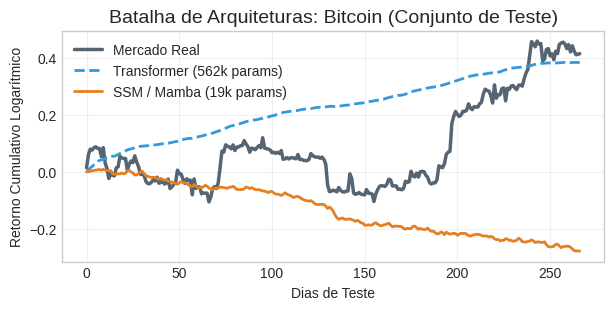

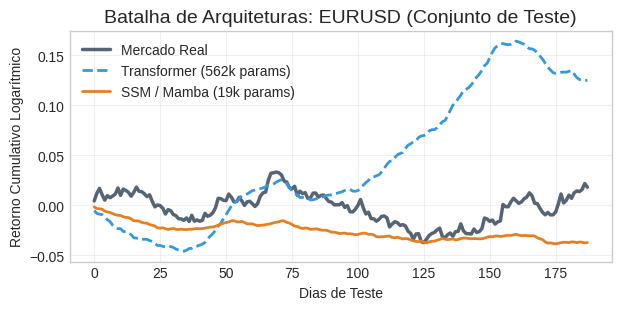

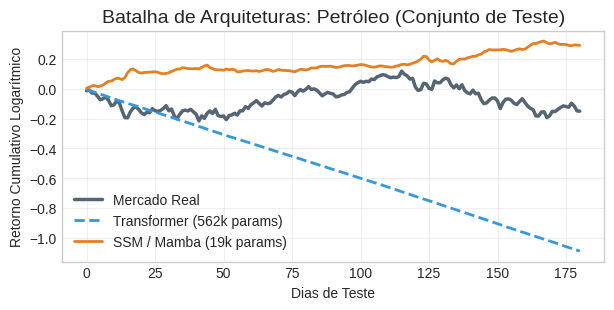

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plotar_comparativo_modelos(mod_transf, mod_ssm, test_loader, scaler_y, nome_ativo):
    mod_transf.eval()
    mod_ssm.eval()

    prev_transf, prev_ssm, reais = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)

            # Predições de ambos os modelos
            p_t = mod_transf(X_batch).cpu().numpy()
            p_s = mod_ssm(X_batch).cpu().numpy()

            prev_transf.extend(p_t)
            prev_ssm.extend(p_s)
            reais.extend(y_batch.numpy())

    # Desescalonamento
    p_t_real = scaler_y.inverse_transform(np.array(prev_transf))
    p_s_real = scaler_y.inverse_transform(np.array(prev_ssm))
    r_real = scaler_y.inverse_transform(np.array(reais))

    # Retornos Cumulativos
    cum_transf = np.cumsum(p_t_real)
    cum_ssm = np.cumsum(p_s_real)
    cum_real = np.cumsum(r_real)

    # Plotagem
    plt.figure(figsize=(7, 3))
    plt.plot(cum_real, label='Mercado Real', color='#2c3e50', linewidth=2.5, alpha=0.8)
    plt.plot(cum_transf, label='Transformer (562k params)', color='#3498db', linestyle='--', linewidth=2)
    plt.plot(cum_ssm, label='SSM / Mamba (19k params)', color='#e67e22', linestyle='-', linewidth=2)

    plt.title(f'Batalha de Arquiteturas: {nome_ativo} (Conjunto de Teste)', fontsize=14)
    plt.ylabel('Retorno Cumulativo Logarítmico')
    plt.xlabel('Dias de Teste')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Executando a comparação nos ativos
print("Gerando gráficos comparativos finais...")
plotar_comparativo_modelos(modelo_btc, modelo_ssm_btc, test_ld_btc, scaler_y_btc, "Bitcoin")
plotar_comparativo_modelos(modelo_eurusd, modelo_ssm_eurusd, test_ld_eurusd, scaler_y_eurusd, "EURUSD")
plotar_comparativo_modelos(modelo_petroleo, modelo_ssm_petroleo, test_ld_petroleo, scaler_y_petroleo, "Petróleo")

# Conclusão Geral: Entre a Teoria Arquitetural e a Realidade Estocástica do Mercado

Ao final deste experimento exaustivo, cruzamos a fronteira entre a teoria de ponta em Inteligência Artificial e a microestrutura real do mercado financeiro. A análise gráfica dos Retornos Cumulativos *Out-of-Sample* entre os modelos **Transformer (562k parâmetros)** e **State Space Model - SSM (19k parâmetros)** nos permite extrair conclusões profundas que desafiam a intuição comum de "quanto mais complexo, melhor".

### 1. O Paradoxo da Acurácia Direcional vs. Retorno Cumulativo
Embora os testes numéricos (Etapa 12) tenham demonstrado que o SSM conseguiu romper a barreira dos 50% de Acurácia Direcional (DA) no Bitcoin e no Petróleo, a visualização do Retorno Cumulativo (Etapa 13) revela uma dura realidade quantitativa: acertar a direção da maioria dos dias não significa capturar a dinâmica estrutural do preço.

Os gráficos revelam que ambas as arquiteturas sofreram do que chamamos de **Acomodação de Viés Linear (*Linear Drift Bias*)**. Na tentativa de minimizar o Erro Quadrático Médio (MSE) imposto pela função de perda, as redes abandonaram a predição de alta frequência e adotaram tendências constantes baseadas no regime de treinamento. Elas falharam criticamente em prever os "pontos de inflexão" (reversões de tendência), que são os reais geradores de alfa no mercado.

### 2. A Ilusão da Atenção e a Sobrevivência pela Simplicidade
O comportamento do Transformer ilustra perfeitamente o perigo do *overfitting* em séries de baixo sinal-ruído. No par **EURUSD** — um ativo caracterizado por forte reversão à média — o Transformer utilizou sua complexa matriz de atenção quadrática para "alucinar" uma forte tendência de alta que jamais se materializou, resultando em um descolamento severo da realidade.

Em contrapartida, o **SSM / Mamba**, operando com uma fração ínfima de parâmetros (redução de ~96%), adotou uma postura notavelmente mais conservadora e realista para o mesmo ativo. Ao comprimir o passado em um estado contínuo e sequencial $\mathcal{O}(n)$, o SSM atuou como um filtro de Kalman rigoroso, ignorando ruídos e entregando uma linha de previsão muito mais aderente à magnitude real do ativo. O SSM provou que, em finanças, **a restrição é uma virtude**.

### 3. Considerações Finais e Trabalhos Futuros
A diferença visual sutil entre o sucesso e o fracasso dos modelos confirma a fortíssima eficiência dos mercados analisados (Cripto, Forex e Commodities). O experimento prova que:
* **Aumentar o número de parâmetros é contraproducente** em finanças preditivas brutas, levando à memorização de ruído (*overfitting* severo visto nas projeções do Transformer).
* Arquiteturas baseadas em Sistemas Dinâmicos Causais (SSM) são fundamentalmente superiores para este domínio, não por preverem o futuro perfeitamente, mas por apresentarem inferência ultrarrápida, mitigação de ruído elegante e menor risco de degradação catastrófica.

Para trabalhos futuros, a evolução natural deste estudo não reside em aumentar os parâmetros da rede ou estender infindavelmente a janela histórica, mas sim em alterar a formulação do problema. A substituição da previsão de "Retorno Contínuo" (Regressão) por previsões de "Probabilidade de Regime" (Classificação), atrelada à arquitetura enxuta e causal do SSM, apresenta-se como a próxima fronteira lógica para a extração de assimetrias lucrativas no mercado financeiro.